In [1]:
from pathlib import Path
import re
import pandas as pd
import seaborn as sns

In [2]:
WORKLOADS = ["faiss_10M", "lulesh2.0_s400", "DuckDB-TPCH-sf100", "DuckDB-TPCDS-sf100", "mg.D.x", "XSBench", "pr-kron.sg", "pr-twitter.sg", "bc-kron.sg", "bc-twitter.sg"]

In [3]:
def parse_time_value(raw: str) -> float:
    """Convert strings like '7m56.676s' into seconds."""
    
    raw = raw.strip()
    match = re.fullmatch(r"(?:(\d+)m)?([0-9.]+)s", raw)
    if not match:
        raise ValueError(f"Unrecognized time format: {raw}")
    minutes = int(match.group(1) or 0)
    seconds = float(match.group(2))
    return minutes * 60 + seconds

def parse_time_file(path: Path) -> dict:
    metrics = {}
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line or "\t" not in line:
                continue
            key, value = line.split("\t", 1)
            metrics[key] = parse_time_value(value)
    return metrics

def extract_mib(path: Path) -> int | None:
    match = re.search(r"(\d+)MiB", path.name)
    return int(match.group(1)) if match else None

def parse_log_file(path: Path) -> dict:
    metrics = {}
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line or "=" not in line:
                continue
            key, value = line.split("=", 1)
            metrics[key.strip()] = float(value.strip())
    return metrics

In [4]:
dfs = []

for workload in WORKLOADS:
    roots = {
        "arms": Path(f"/users/zimooo2/tiering_solutions/times/arms/{workload}"),
        "hybridtier": Path(f"/users/zimooo2/tiering_solutions/times/hybridtier/{workload}"),
    }

    records: list[dict] = []
    for label, root in roots.items():
        for path in sorted(root.glob("*.time")):
            if "train" in path.name:
                continue
            metrics = parse_time_file(path)
            try:
                log_metrics = parse_log_file(Path(f"{path.parent}/max_dram_hugepages_{path.stem}.log"))
            except FileNotFoundError:
                log_metrics = {}
                
                
            
                
            m = re.search(
                r"_discounted_reward_(\d+)_.*_l2-(true|false)_(\d+)_([0-9]*\.?[0-9]+)\.time$",
                path.name,
            )
            parsed = {}
            if m:
                parsed = {
                    "discounted_reward": int(m.group(1)),
                    "minmax": m.group(2) == "true",
                    "hist_length": int(m.group(3)),
                    "penalty": float(m.group(4)),
                }

            records.append({
                "policy": label,
                "file": path.name,
                "MiB": extract_mib(path),
                **metrics,
                **log_metrics,
                **parsed,
            })

    df = pd.DataFrame(records)
    df["workload"] = workload

    dfs.append(df)
df = pd.concat(dfs, ignore_index=True)
df


arms_df = (
    df.loc[df["policy"] == "arms", ["MiB", "workload", "real"]]
    .rename(columns={"real": "real_arms"})
    .drop_duplicates(subset=["MiB", "workload"])
)

df = (
    df.loc[df["policy"] != "arms"]
    .merge(arms_df, on=["MiB", "workload"], how="left")
)

# >1 means faster than arms, <1 means slower than arms
df["relative_score_vs_arms"] = df["real_arms"] / df["real"]
df

,policy,file,MiB,real,user,sys,workload,real_arms,relative_score_vs_arms
0,hybridtier,1MiB_run1.time,1,28.485,3.201,26.253,faiss_10M,0.061,0.002141
1,hybridtier,4000MiB_run1.time,4000,580.067,2919.106,71.018,faiss_10M,555.049,0.956870
2,hybridtier,4000MiB_run1.time,4000,499.747,4706.923,1970.132,lulesh2.0_s400,493.377,0.987254
3,hybridtier,4000MiB_run1.time,4000,450.979,5663.186,471.856,DuckDB-TPCH-sf100,510.503,1.131988
4,hybridtier,4000MiB_run1.time,4000,1486.157,16092.324,1432.121,DuckDB-TPCDS-sf100,1447.323,0.973870
5,hybridtier,4000MiB_run1.time,4000,528.393,7623.340,105.569,mg.D.x,554.603,1.049603
6,hybridtier,1MiB_run1.time,1,342.646,4183.957,78.313,XSBench,25.826,0.075372
7,hybridtier,4000MiB_run1.time,4000,210.847,2049.366,68.511,XSBench,340.330,1.614109
8,hybridtier,4000MiB_run1.time,4000,400.864,4338.441,98.749,pr-kron.sg,406.404,1.013820
9,hybridtier,4000MiB_run1.time,4000,NaN,NaN,NaN,pr-twitter.sg,363.411,NaN


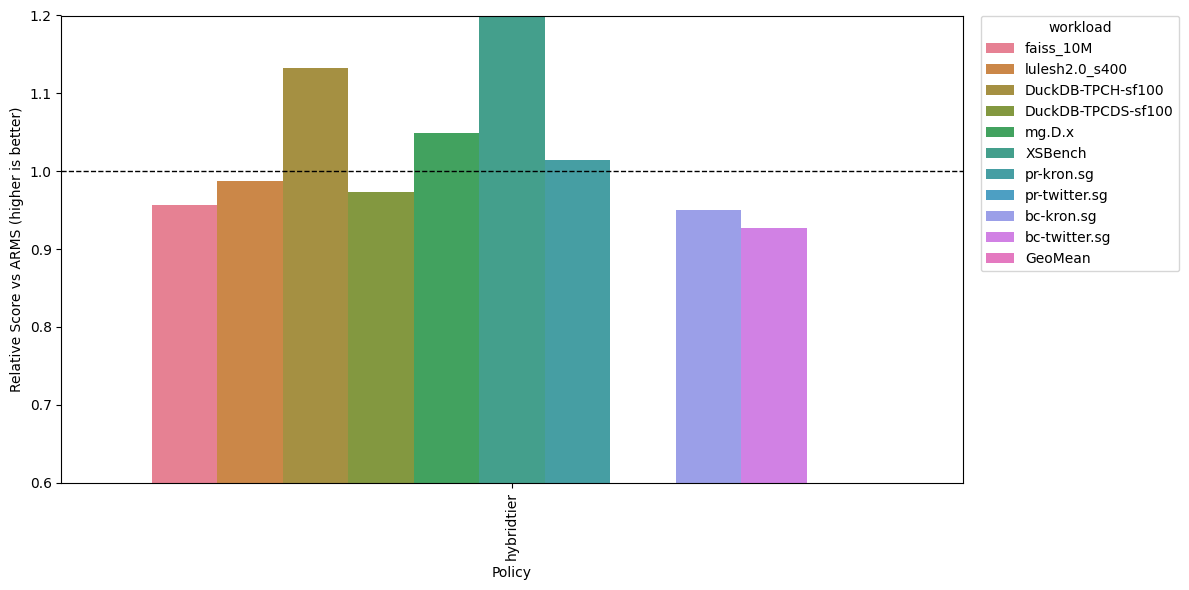

In [5]:
geomean_rows = (
    df.dropna(subset=["relative_score_vs_arms"])
      .groupby(["MiB"], as_index=False)["relative_score_vs_arms"]
      .agg(lambda s: s.prod() ** (1 / len(s)))
)

geomean_rows["workload"] = "GeoMean"



df = pd.concat([df, geomean_rows], ignore_index=True, sort=False)
df_graph = df[df["MiB"] == 4000][["policy", "relative_score_vs_arms", "workload"]].dropna(axis=0)
df_graph["workload"] = pd.Categorical(df_graph["workload"], categories=WORKLOADS + ["GeoMean"], ordered=True)

sns.barplot(
  df_graph,
  x="policy",
  y="relative_score_vs_arms",
  hue="workload"
).set(ylim=(0.6,1.2), ylabel="Relative Score vs ARMS (higher is better)", xlabel="Policy")
import matplotlib.pyplot as plt
plt.axhline(y=1.0, color="black", linestyle="--", linewidth=1)
plt.xticks(rotation=90)
plt.gcf().set_size_inches(12, 6)
ax = plt.gca()
ax.legend(title="workload", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()



In [ ]:
geomean_rows = (
    df.dropna(subset=["relative_score_vs_arms"])
      .groupby(["MiB", "id"], as_index=False)["relative_score_vs_arms"]
      .agg(lambda s: s.prod() ** (1 / len(s)))
)

geomean_rows["workload"] = "GeoMean"

sns.barplot(df[df["MiB"] == 1500], x="id", y="relative_score_vs_arms", hue="workload").set(ylim=(0.8,1.2), ylabel="Relative Score vs ARMS (higher is better)", xlabel="Policy Configuration\n(Objective Value, Smoothing Function, History Length, Penalty)")
import matplotlib.pyplot as plt
plt.axhline(y=1.0, color="black", linestyle="--", linewidth=1)
plt.xticks(rotation=90)
plt.gcf().set_size_inches(12, 6)
ax = plt.gca()
ax.legend(title="workload", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout(rect=[0, 0, 0.85, 1])

KeyError: 'id'

: 